# 8. Two-Stage Model

**Project:** Predicting colorectal cancer screening non-compliance to guide targeted outreach
**Part of:** the two-stage follow-up scoped out in `3 Data Processing.ipynb` and motivated by
`2 Exploratory Data Analysis.ipynb` section 4, which found "never screened" and "overdue" behave
like different problems -- insurance and age barely move the overdue rate (a roughly flat 5-9%
baseline) but swing the never-screened rate enormously (17% insured vs. 62% uninsured; 51% at
ages 45-49 vs. 7% at 75-79). That EDA finding suggested two separate outreach tracks rather than
one generic non-compliance flag. Notebook 3 defined the two target columns for this
(`never_screened`, `overdue_given_screened`) and explicitly deferred modelling them -- this
notebook is that deferred follow-up.

**Three parts, in one notebook:**
1. **Never-screened model** -- fit on the whole eligible population.
2. **Overdue-given-screened model** -- fit on the subset who have been screened at least once.
3. **Combination** -- recombine both stages into one risk score and compare against the primary
   single-stage model (`gb_M3_tuned`), both on ranking performance and on what each stage reveals
   about its own, narrower prediction problem.

**Scope, deliberately smaller than the primary model:** one interpretable baseline (logistic
regression) plus one non-linear model (gradient boosting, reusing `gb_M3_tuned`'s already-tuned
hyperparameters rather than re-running a search) per stage, M3 features only -- not the full
four-family, three-domain treatment `4a`-`4d` gave the primary target. This is a secondary,
exploratory follow-up motivated by the EDA, not part of the proposal's required methodology.

**Is this the official model?** No -- recommended against, see the closing note at the end of
Part 3 for the reasoning. `gb_M3_tuned` (and its calibrated variant from `5 Evaluation.ipynb`)
remains the model the rest of the project (calibration, risk deciles, subgroup equity, robustness
checks) is built around.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

sys.path.insert(0, str(Path.cwd()))
from pipeline_components import (
    RANDOM_SEED, M3_FEATURES, build_logreg_pipeline, build_gb_pipeline,
    compute_classification_metrics, make_model_registry,
)

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROCESSED_DIR / "modelling"
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Separate registry from the primary single-target models (4a-4d/5-7) -- different targets, not
# directly comparable metric-for-metric against crc_noncompliant, so kept in their own manifest.
TWOSTAGE_MODELS_DIR = MODEL_DIR / "twostage_models"
TWOSTAGE_MANIFEST_PATH = MODEL_DIR / "twostage_model_registry_manifest.csv"
_, register_model, load_twostage_registry = make_model_registry(TWOSTAGE_MODELS_DIR, TWOSTAGE_MANIFEST_PATH)

_, _, load_primary_registry = make_model_registry(MODEL_DIR / "models", MODEL_DIR / "model_registry_manifest.csv")
primary_registry = load_primary_registry()

# Reuse the primary target's already-tuned gradient boosting hyperparameters for both stages below,
# rather than running a fresh RandomizedSearchCV for a secondary, out-of-proposal-scope target.
tuned_gb_params = {
    k: v for k, v in primary_registry["gb_M3_tuned"]["pipeline"].named_steps["model"].get_params().items()
    if k in ["learning_rate", "max_iter", "max_leaf_nodes", "max_depth", "min_samples_leaf", "l2_regularization"]
}

ANALYTIC_PATH = PROCESSED_DIR / "crc_analytic_dataset.csv"
SPLIT_PATH = MODEL_DIR / "train_calibration_test_split.csv"
for p in [ANALYTIC_PATH, SPLIT_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"{p} not found. Run '1 Data Preparation.ipynb' and '3 Data Processing.ipynb' first.")

df = pd.read_csv(ANALYTIC_PATH, dtype={"respondent_id": "string", "state_fips": "string"}, low_memory=False)
split_assignment = pd.read_csv(SPLIT_PATH, dtype={"respondent_id": "string"})
df = df.merge(split_assignment, on="respondent_id", validate="one_to_one")

# Recompute both two-stage targets here -- notebook 3 defined them but never persisted them to a file.
df["never_screened"] = (df["crc_screening_status"] == "Never screened").astype(int)
ever_screened_mask = df["crc_screening_status"].isin(["Up to date", "Overdue"])
df["overdue_given_screened"] = np.where(ever_screened_mask, (df["crc_screening_status"] == "Overdue").astype(int), np.nan)

print("Shared setup ready. Two-stage targets defined:", df[["never_screened"]].sum().to_dict())

Shared setup ready. Two-stage targets defined: {'never_screened': 43930}


## Part 1: Never-screened model

**Target:** `never_screened` -- 1 if the respondent has never had any recommended CRC test, 0 if
they have (whether currently up to date or overdue). Defined for the **whole eligible
population** (same 227,647 respondents, same train/calibration/test split as the primary model).

In [2]:
X_train_never = df.loc[df["split"] == "train", M3_FEATURES]
y_train_never = df.loc[df["split"] == "train", "never_screened"]
X_test_never = df.loc[df["split"] == "test", M3_FEATURES]
y_test_never = df.loc[df["split"] == "test", "never_screened"]

for name, ys in [("train", y_train_never), ("test", y_test_never)]:
    print(f"{name:6s} n={len(ys):>7,}   never-screened rate={ys.mean():.4f}")

w_train_never = compute_sample_weight("balanced", y_train_never)

never_logreg_pipe = build_logreg_pipeline(M3_FEATURES)
never_logreg_pipe.fit(X_train_never, y_train_never, model__sample_weight=w_train_never)

never_gb_pipe = build_gb_pipeline(M3_FEATURES)
never_gb_pipe.named_steps["model"].set_params(**tuned_gb_params)
never_gb_pipe.fit(X_train_never, y_train_never, model__sample_weight=w_train_never)

never_screened_probas = {}
never_screened_rows = []
for model_name, pipe in [("logreg", never_logreg_pipe), ("gb", never_gb_pipe)]:
    proba = pipe.predict_proba(X_test_never)[:, 1]
    metrics = compute_classification_metrics(y_test_never, proba)
    never_screened_probas[model_name] = proba
    never_screened_rows.append({"Model": model_name, **metrics})
    register_model(
        name=f"never_screened_{model_name}_M3", pipeline=pipe, metrics=metrics, features=M3_FEATURES,
        model_type=f"Never-screened {model_name} (class-weighted{', tuned GB hyperparameters reused from gb_M3_tuned' if model_name == 'gb' else ''})",
        notes="Stage 1 of the two-stage follow-up; target is never_screened, whole eligible population.",
    )

pd.DataFrame(never_screened_rows).round(4)

train  n=136,588   never-screened rate=0.1931
test   n= 45,530   never-screened rate=0.1922


,Model,AUROC,AUPRC,Precision,Sensitivity,Specificity,F1,Accuracy
0,logreg,0.8105,0.5581,0.4115,0.7266,0.7527,0.5254,0.7477
1,gb,0.8208,0.5739,0.4280,0.7230,0.7701,0.5377,0.7610


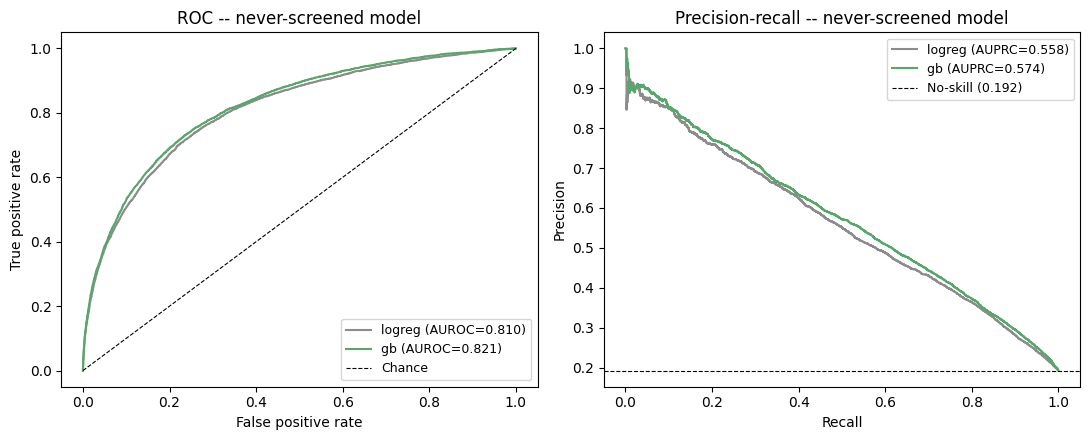

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = {"logreg": "#8C8C8C", "gb": "#55A868"}

for model_name in ["logreg", "gb"]:
    proba = never_screened_probas[model_name]
    fpr, tpr, _ = roc_curve(y_test_never, proba)
    auroc = roc_auc_score(y_test_never, proba)
    axes[0].plot(fpr, tpr, color=colors[model_name], label=f"{model_name} (AUROC={auroc:.3f})")
    precision, recall, _ = precision_recall_curve(y_test_never, proba)
    auprc = average_precision_score(y_test_never, proba)
    axes[1].plot(recall, precision, color=colors[model_name], label=f"{model_name} (AUPRC={auprc:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=0.8, label="Chance")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC -- never-screened model"); axes[0].legend(loc="lower right", fontsize=9)
axes[1].axhline(y_test_never.mean(), linestyle="--", color="black", linewidth=0.8, label=f"No-skill ({y_test_never.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall -- never-screened model"); axes[1].legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig25_never_screened_roc_pr.png", dpi=150)
plt.show()

**Reading this:** both models separate never-screened respondents considerably better than the
primary `crc_noncompliant` model separated its blended target -- AUROC 0.811 (logistic regression)
and 0.821 (gradient boosting) here, versus 0.755/0.766 for the equivalent primary-target models.
This is consistent with the EDA's own finding: "never screened" has a much steeper, more
structured relationship with access and demographics than the collapsed binary outcome does, so
isolating it as its own target makes it an easier prediction problem, not a harder one. Gradient
boosting leads on every metric, as it did for the primary target, but the gap to logistic
regression is narrower here (0.010 AUROC), suggesting less of this target's signal is non-linear.

**Analysis of factors:** permutation importance on the gradient boosting model, same method as
`4b`-`4d`, for comparability with the primary target's factor rankings.

In [4]:
rng = np.random.RandomState(RANDOM_SEED)
perm_sample_idx = rng.choice(X_test_never.index, size=15_000, replace=False)
perm_result = permutation_importance(
    never_gb_pipe, X_test_never.loc[perm_sample_idx], y_test_never.loc[perm_sample_idx],
    n_repeats=5, random_state=RANDOM_SEED, scoring="roc_auc", n_jobs=-1,
)
never_screened_importance = pd.DataFrame({
    "feature": M3_FEATURES,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)
never_screened_importance.to_csv(MODEL_DIR / "never_screened_permutation_importance.csv", index=False)
never_screened_importance.round(4)

,feature,importance_mean,importance_std
0,age_group,0.1112,0.0040
11,checkup_recency,0.0329,0.0009
3,education_level,0.0107,0.0013
4,income_group,0.0101,0.0007
5,employment_status,0.0095,0.0008
9,personal_doctor,0.0073,0.0008
15,smoking_status,0.0052,0.0006
2,race_ethnicity,0.0050,0.0006
6,marital_status,0.0032,0.0003
8,insurance_status,0.0030,0.0004


**Reading this:** `age_group` dominates even more heavily here (mean AUROC drop ~0.111) than it
did for the primary target (~0.077-0.079 across the three non-linear models in `4b`-`4d`) --
consistent with the EDA's age breakdown, where never-screened rates ranged from 50.9% (45-49) down
to 7.0% (75-79). `checkup_recency` is a distant second (~0.033, versus ~0.041-0.043 for the primary
target). `education_level`, `income_group` and `employment_status` form a modest secondary tier,
broadly consistent with the demographic/access story running through the rest of the project.

## Part 2: Overdue-given-screened model

**Target:** `overdue_given_screened` -- 1 if a respondent who has been screened at least once is
now overdue, 0 if up to date. **Only defined for respondents who have ever been screened**
(`crc_screening_status` in `{"Up to date", "Overdue"}`, n=183,717 of the 227,647 eligible
respondents), unlike Part 1's target, which applies to everyone. The train/calibration/test split
is the same respondent-level assignment used throughout the project, just restricted to this
subset.

In [5]:
df_screened = df.loc[ever_screened_mask].copy()
print(f"Ever-screened subset: n={len(df_screened):,} of {len(df):,} eligible respondents")

X_train_screened = df_screened.loc[df_screened["split"] == "train", M3_FEATURES]
y_train_screened = df_screened.loc[df_screened["split"] == "train", "overdue_given_screened"].astype(int)
X_test_screened = df_screened.loc[df_screened["split"] == "test", M3_FEATURES]
y_test_screened = df_screened.loc[df_screened["split"] == "test", "overdue_given_screened"].astype(int)

for name, ys in [("train", y_train_screened), ("test", y_test_screened)]:
    print(f"{name:6s} n={len(ys):>7,}   overdue-given-screened rate={ys.mean():.4f}")

w_train_screened = compute_sample_weight("balanced", y_train_screened)

overdue_logreg_pipe = build_logreg_pipeline(M3_FEATURES)
overdue_logreg_pipe.fit(X_train_screened, y_train_screened, model__sample_weight=w_train_screened)

overdue_gb_pipe = build_gb_pipeline(M3_FEATURES)
overdue_gb_pipe.named_steps["model"].set_params(**tuned_gb_params)
overdue_gb_pipe.fit(X_train_screened, y_train_screened, model__sample_weight=w_train_screened)

overdue_probas = {}
overdue_rows = []
for model_name, pipe in [("logreg", overdue_logreg_pipe), ("gb", overdue_gb_pipe)]:
    proba = pipe.predict_proba(X_test_screened)[:, 1]
    metrics = compute_classification_metrics(y_test_screened, proba)
    overdue_probas[model_name] = proba
    overdue_rows.append({"Model": model_name, **metrics})
    register_model(
        name=f"overdue_given_screened_{model_name}_M3", pipeline=pipe, metrics=metrics, features=M3_FEATURES,
        model_type=f"Overdue-given-screened {model_name} (class-weighted{', tuned GB hyperparameters reused from gb_M3_tuned' if model_name == 'gb' else ''})",
        notes="Stage 2 of the two-stage follow-up; target is overdue_given_screened, ever-screened subset only.",
    )

pd.DataFrame(overdue_rows).round(4)

Ever-screened subset: n=183,717 of 227,647 eligible respondents
train  n=110,213   overdue-given-screened rate=0.0888
test   n= 36,778   overdue-given-screened rate=0.0898


,Model,AUROC,AUPRC,Precision,Sensitivity,Specificity,F1,Accuracy
0,logreg,0.6213,0.1698,0.1359,0.4799,0.6988,0.2118,0.6792
1,gb,0.6251,0.1714,0.1332,0.4777,0.6933,0.2084,0.6740


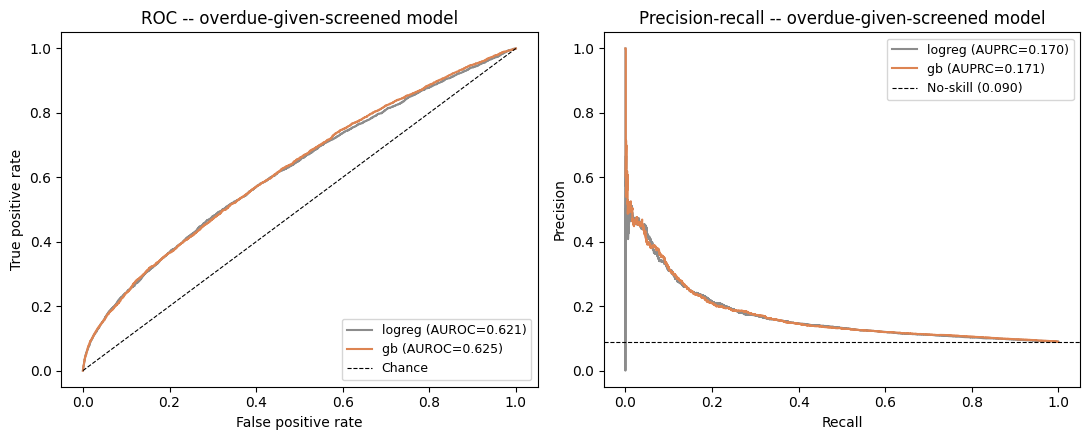

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = {"logreg": "#8C8C8C", "gb": "#DD8452"}

for model_name in ["logreg", "gb"]:
    proba = overdue_probas[model_name]
    fpr, tpr, _ = roc_curve(y_test_screened, proba)
    auroc = roc_auc_score(y_test_screened, proba)
    axes[0].plot(fpr, tpr, color=colors[model_name], label=f"{model_name} (AUROC={auroc:.3f})")
    precision, recall, _ = precision_recall_curve(y_test_screened, proba)
    auprc = average_precision_score(y_test_screened, proba)
    axes[1].plot(recall, precision, color=colors[model_name], label=f"{model_name} (AUPRC={auprc:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=0.8, label="Chance")
axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC -- overdue-given-screened model"); axes[0].legend(loc="lower right", fontsize=9)
axes[1].axhline(y_test_screened.mean(), linestyle="--", color="black", linewidth=0.8, label=f"No-skill ({y_test_screened.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall -- overdue-given-screened model"); axes[1].legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig26_overdue_given_screened_roc_pr.png", dpi=150)
plt.show()

**Reading this:** this target is much harder to predict than either the primary `crc_noncompliant`
model (AUROC 0.755-0.766) or Part 1's never-screened model (0.811-0.821) -- both models here land
around AUROC 0.62-0.63, barely above chance, and gradient boosting doesn't clearly beat logistic
regression (0.625 vs. 0.621). This directly confirms the EDA's hypothesis from section 4: "overdue"
behaves like a roughly uniform background rate these predictors don't explain well, unlike "never
screened." Practically, this supports a generic reminder/recall system for the overdue group
rather than a targeted, risk-scored intervention, since there isn't much learnable signal here.

**Analysis of factors**, same method as Part 1.

In [7]:
perm_n = min(15_000, len(X_test_screened))
rng_overdue = np.random.RandomState(RANDOM_SEED)  # fresh RNG, not the Part 1 one -- keeps this section's
                                                   # sample reproducible on its own, matching the numbers below
perm_sample_idx = rng_overdue.choice(X_test_screened.index, size=perm_n, replace=False)
perm_result = permutation_importance(
    overdue_gb_pipe, X_test_screened.loc[perm_sample_idx], y_test_screened.loc[perm_sample_idx],
    n_repeats=5, random_state=RANDOM_SEED, scoring="roc_auc", n_jobs=-1,
)
overdue_importance = pd.DataFrame({
    "feature": M3_FEATURES,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)
overdue_importance.to_csv(MODEL_DIR / "overdue_given_screened_permutation_importance.csv", index=False)
overdue_importance.round(4)

,feature,importance_mean,importance_std
11,checkup_recency,0.0350,0.0017
0,age_group,0.0113,0.0032
2,race_ethnicity,0.0106,0.0029
4,income_group,0.0095,0.0036
6,marital_status,0.0077,0.0024
7,urban_rural,0.0052,0.0010
12,general_health,0.0050,0.0017
5,employment_status,0.0049,0.0025
15,smoking_status,0.0034,0.0015
9,personal_doctor,0.0032,0.0010


**Reading this:** `checkup_recency` leads, but only modestly (~0.035) -- and everything else is
small. Most tellingly, `age_group` -- the dominant factor everywhere else in this project
(~0.077-0.111 mean AUROC drop in every other model) -- drops to ~0.011 here, barely above the
noise floor, matching the EDA's age breakdown almost exactly (overdue rates ranged only
5.0%-8.7% across every age band). That's a genuine, informative null result: the predictors this
whole project is built around simply don't carry much signal for who, among people who've already
engaged with screening once, has since fallen behind.

## Part 3: Combining the two stages

Combines Part 1's and Part 2's models back into a single non-compliance risk score, and checks two
questions against the primary single-stage model (`gb_M3_tuned`): does decomposing the outcome
into two stages *help or hurt* ranking performance on the original `crc_noncompliant` target, and
-- separately, more relevant to the EDA's "two outreach tracks" idea -- how well does each stage do
at its own, narrower job.

**How the combination works:** the original 3-category outcome decomposes as
`P(non-compliant) = P(never screened) + P(screened) x P(overdue | screened)`. Part 1 gives
`P(never screened)` directly for everyone. Part 2 gives `P(overdue | screened)`, but it was only
*trained* on respondents who have actually been screened -- applying it to respondents who were
never screened means asking it "if this person *had* been screened, how likely would they be
overdue," an extrapolation beyond its training distribution, not an empirically validated
prediction for that subgroup. Standard for combining staged/hurdle-style models, but worth being
explicit that this one piece is an assumption, not something the data directly checked.

In [8]:
X_test_primary = df.loc[df["split"] == "test", M3_FEATURES]
y_test_primary = df.loc[df["split"] == "test", "crc_noncompliant"]

p_never_screened = never_gb_pipe.predict_proba(X_test_primary)[:, 1]
p_overdue_given_screened = overdue_gb_pipe.predict_proba(X_test_primary)[:, 1]
p_combined = p_never_screened + (1 - p_never_screened) * p_overdue_given_screened

primary_model = primary_registry["gb_M3_tuned"]["pipeline"]
p_primary = primary_model.predict_proba(X_test_primary)[:, 1]

assert (p_combined >= 0).all() and (p_combined <= 1).all(), "combined probability out of [0,1] range"

combined_metrics = compute_classification_metrics(y_test_primary, p_combined)
primary_metrics = compute_classification_metrics(y_test_primary, p_primary)

stage_comparison = pd.DataFrame([
    {"Approach": "Single-stage (gb_M3_tuned)", **primary_metrics},
    {"Approach": "Two-stage (combined)", **combined_metrics},
])
stage_comparison.round(4)

,Approach,AUROC,AUPRC,Precision,Sensitivity,Specificity,F1,Accuracy
0,Single-stage (gb_M3_tuned),0.7662,0.5974,0.4910,0.6385,0.7617,0.5551,0.7291
1,Two-stage (combined),0.7650,0.5946,0.3022,0.9490,0.2107,0.4584,0.4062


**Reading the ranking metrics (AUROC/AUPRC):** the two approaches are essentially tied --
AUROC 0.7662 (single-stage) vs. 0.7650 (two-stage combined), AUPRC 0.5974 vs. 0.5946. Decomposing
the outcome into two stages and recombining it neither meaningfully helps nor hurts overall
ranking.

**The fixed-threshold metrics are a different story, and misleading at face value.** Sensitivity
jumps to 0.949 but precision collapses to 0.302 and accuracy falls to 0.406 -- far worse than the
single-stage model's 0.729. This is the same `sample_weight="balanced"` probability-inflation
problem from `5 Evaluation.ipynb`'s calibration section, compounded twice: Parts 1 and 2 were each
fit with class weighting that pushes raw probabilities above the true rate, and
`p_combined = p_never + (1-p_never) x p_overdue` multiplies two already-inflated numbers together,
pushing the combined score even higher. At an uncalibrated 0.5 threshold, it now flags far more
people than it should -- not evidence the approach is worse, just a reminder that raw
class-weighted probabilities need calibration before being read at face value. AUROC/AUPRC are the
fair, threshold-free comparison, and by that measure the two approaches are a genuine tie.

**Each stage's own performance, side by side** -- the table above answers "does splitting the
target help the original ranking task." This one answers the EDA's actual original question: how
good is each stage at its own, narrower job.

In [9]:
twostage_registry = load_twostage_registry()
stage_own_performance = pd.DataFrame([
    {"Stage": "Stage 1: never-screened (whole population)", **twostage_registry["never_screened_gb_M3"]["metrics"]},
    {"Stage": "Stage 2: overdue-given-screened (screened subset)", **twostage_registry["overdue_given_screened_gb_M3"]["metrics"]},
    {"Stage": "Single-stage: crc_noncompliant (whole population)", **primary_metrics},  # reuse the freshly-computed metrics above -- the manifest's stored metrics predate the specificity fix for this model
])
stage_own_performance.round(4)

,Stage,AUROC,AUPRC,Precision,Sensitivity,Specificity,F1,Accuracy
0,Stage 1: never-screened (whole population),0.8208,0.5739,0.4280,0.7230,0.7701,0.5377,0.7610
1,Stage 2: overdue-given-screened (screened subset),0.6251,0.1714,0.1332,0.4777,0.6933,0.2084,0.6740
2,Single-stage: crc_noncompliant (whole population),0.7662,0.5974,0.4910,0.6385,0.7617,0.5551,0.7291


**This is where the two-stage idea actually pays off -- not in the combined ranking score, but
in what it reveals about the two sub-problems separately.** Stage 1 is predictable with real
accuracy (AUROC 0.821, above even the single-stage model's 0.766). Stage 2 is barely predictable
at all (AUROC 0.625). The single combined model's AUROC (0.766) sits between the two, implicitly
averaging an easy sub-problem with a hard one, without ever telling the user which respondents
fall into which category.

**Practical implication, matching the EDA's suggestion in `2 Exploratory Data Analysis.ipynb`
section 4:** these results support two different outreach tracks rather than one score. For
"never screened," a targeted, risk-scored campaign (using Part 1's model, calibrated first, the
same way `5 Evaluation.ipynb` calibrated the primary model) makes sense, focused on access
barriers. For "overdue," a generic reminder/recall system reaching everyone overdue -- rather than
a targeted campaign -- is the better-supported strategy, since there isn't a strong learnable
signal here to prioritise by.

**Should this replace `gb_M3_tuned` as the official model? No.** Three reasons: ranking
performance is a tie, not an improvement, so there's no predictive case for switching. The
proposal's committed methodology is built around the single collapsed binary outcome (Section 2:
"`crc_noncompliant` = 0 if `_CRCREC3` = 1, else 1"), and the two-stage decomposition is an
EDA-motivated extension beyond that, not a replacement for it. And promoting it would mean redoing
calibration, risk deciles, subgroup equity and robustness checks for two models (or the compound
score) instead of one -- real rework for a tied result. Its value is the operational insight above,
not as a drop-in replacement -- best presented as a supplementary finding alongside the primary
model, not instead of it.